# Post-Only vs Trajectory Supervision for Continual Tool-Use Learning
## Experiment on H100 (80GB)

**Goal**: Compare two training conditions:
- **Condition A (Post-Only)**: Train only on the final assistant response
- **Condition B (Trajectory)**: Train on the full trace (user → tool call → tool output → response)

We fine-tune **Mistral-7B-Instruct-v0.3** with QLoRA on API-Bank data, split into sequential domain blocks, and measure adaptation speed and catastrophic forgetting.

**Hardware**: H100 80GB — using bf16, PyTorch SDPA attention, large batches

**Dataset**: API-Bank training data (1,888 dialogues across ~1,000 domains)

## 1. Setup & Installation

In [ ]:
!pip install -q transformers datasets accelerate peft bitsandbytes trl huggingface_hub matplotlib seaborn tqdm scikit-learn

In [ ]:
import json
import os
import re
import random
import copy
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from pathlib import Path
from tqdm.auto import tqdm

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments,
    DataCollatorForLanguageModeling,
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, PeftModel
from torch.utils.data import Dataset
from trl import SFTTrainer, SFTConfig

# Reproducibility
SEED = 42
ATTN_IMPLEMENTATION = "sdpa"
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"BF16 support: {torch.cuda.is_bf16_supported()}")
print(f"Attention implementation: {ATTN_IMPLEMENTATION} (flash-attn disabled)")

GPU: NVIDIA H100 80GB HBM3
VRAM: 85.0 GB
BF16 support: True
Attention implementation: sdpa (flash-attn disabled)


## 2. Download & Parse API-Bank Data

In [ ]:
from huggingface_hub import hf_hub_download

# Download training JSON files from API-Bank
data_files = [
    "training-data/lv1-train.json",
    "training-data/lv2-train.json",
    "training-data/lv3-train.json",
]

all_raw = []
for fname in data_files:
    path = hf_hub_download(
        repo_id="liminghao1630/API-Bank",
        filename=fname,
        repo_type="dataset",
    )
    with open(path) as f:
        entries = json.load(f)
    print(f"{fname}: {len(entries)} entries")
    all_raw.extend(entries)

print(f"\nTotal raw entries: {len(all_raw)}")
print(f"\nExample entry keys: {list(all_raw[0].keys())}")
print(f"\nExample instruction (truncated):\n{all_raw[0]['instruction'][:300]}...")
print(f"\nExample input (truncated):\n{all_raw[0]['input'][:300]}...")
print(f"\nExample output:\n{all_raw[0].get('output', 'N/A')}")

training-data/lv1-train.json: 6184 entries
training-data/lv2-train.json: 9279 entries
training-data/lv3-train.json: 1245 entries

Total raw entries: 16708

Example entry keys: ['instruction', 'input', 'output']

Example instruction (truncated):

Generate an API request in the format of [ApiName(key1='value1', key2='value2', ...)] based on the previous dialogue context.
The current time is 2039-03-09 18:56:09 Wednesday.
Input: 
User: User's utterence
AI: AI's response

Expected output:
API-Request: [ApiName(key1='value1', key2='value2', ......

Example input (truncated):
{"apiCode": "Get_All_Sessions", "description": "Get the list of all available yoga and meditation sessions.", "parameters": {}, "response": {"data": {"description": "List of available sessions.", "type": "list", "items": {"type": "object", "properties": {"session_name": {"description": "Name of the ...

Example output:
API-Request: [Get_All_Sessions()]


## 3. Extract API Names & Build Domain Blocks

We group entries by the API they reference, then cluster APIs into domain blocks for continual learning.

In [ ]:
def extract_api_name(entry):
    """Extract the primary API name from an entry's output or input."""
    text = entry.get('output', '') or ''
    # Pattern: [ApiName(...)]
    match = re.search(r'\[([A-Za-z_][A-Za-z0-9_]*)\(', text)
    if match:
        return match.group(1)
    # Also check the input field
    text = entry.get('input', '') or ''
    match = re.search(r'\[([A-Za-z_][A-Za-z0-9_]*)\(', text)
    if match:
        return match.group(1)
    return 'unknown'

# Tag each entry with its API
for entry in all_raw:
    entry['api_name'] = extract_api_name(entry)

# Count entries per API
api_counts = defaultdict(int)
for entry in all_raw:
    api_counts[entry['api_name']] += 1

# Sort by frequency
sorted_apis = sorted(api_counts.items(), key=lambda x: -x[1])
print(f"Total unique APIs: {len(sorted_apis)}")
print(f"\nTop 20 APIs by frequency:")
for api, count in sorted_apis[:20]:
    print(f"  {api}: {count}")
print(f"\n'unknown' entries: {api_counts.get('unknown', 0)}")

Total unique APIs: 1896

Top 20 APIs by frequency:
  ToolSearcher: 6996
  book_appointment: 94
  get_equipment_list: 91
  return_equipment: 78
  schedule_appointment: 71
  add_medication: 71
  cancel_appointment: 63
  get_claim_status: 58
  get_medications: 57
  submit_claim: 52
  get_patient_info: 51
  search_providers: 47
  rent_equipment: 43
  get_classes: 42
  get_exercise_list: 41
  get_available_doctors: 38
  get_medication_info: 36
  get_hospital_list: 36
  get_prescription: 34
  get_nutrition_info: 33

'unknown' entries: 0


In [ ]:
# ============================================================
# Build domain blocks
# We pick the top APIs with enough samples and group them
# into 4 sequential domain blocks.
# ============================================================

# Filter to APIs with at least 10 entries for meaningful training
MIN_ENTRIES = 10
valid_apis = [api for api, count in sorted_apis if count >= MIN_ENTRIES and api != 'unknown']
print(f"APIs with >= {MIN_ENTRIES} entries: {len(valid_apis)}")

# Split into 4 domain blocks (roughly equal)
NUM_BLOCKS = 4
random.shuffle(valid_apis)
block_size = len(valid_apis) // NUM_BLOCKS
domain_blocks = []
for i in range(NUM_BLOCKS):
    start = i * block_size
    end = start + block_size if i < NUM_BLOCKS - 1 else len(valid_apis)
    block_apis = valid_apis[start:end]
    block_entries = [e for e in all_raw if e['api_name'] in block_apis]
    domain_blocks.append({
        'apis': block_apis,
        'entries': block_entries,
    })

for i, block in enumerate(domain_blocks):
    print(f"\nBlock {i+1}: {len(block['apis'])} APIs, {len(block['entries'])} entries")
    print(f"  APIs: {block['apis'][:5]}{'...' if len(block['apis']) > 5 else ''}")

APIs with >= 10 entries: 186

Block 1: 46 APIs, 7949 entries
  APIs: ['get_equipment_list', 'get_exercise_list', 'SearchDoctor', 'schedule_follow_up', 'get_doctor_list']...

Block 2: 46 APIs, 778 entries
  APIs: ['cancel_booking', 'get_medication_info', 'get_workout_plan', 'get_nutrition_list', 'get_coverage_by_disease']...

Block 3: 46 APIs, 753 entries
  APIs: ['Find_Healthcare_Provider', 'get_prescriptions', 'book_equipment', 'search_trials', 'get_device_list']...

Block 4: 48 APIs, 990 entries
  APIs: ['get_maintenance_tips', 'get_exercises', 'add_symptom', 'search_providers', 'add_workout']...


## 4. Format Data for Condition A (Post-Only) vs Condition B (Trajectory)

- **Condition A**: Only the final assistant response as the training target
- **Condition B**: Full trajectory including tool calls and tool outputs

In [ ]:
def format_condition_a(entry):
    """Post-only: strip API calls from input, train on final response."""
    inp = entry['input']
    out = entry.get('output', '')

    # Remove lines that look like API requests/responses from the input
    lines = inp.split('\n')
    filtered_lines = []
    for line in lines:
        if line.strip().startswith('API-Request:') or line.strip().startswith('API-Response:'):
            continue
        if 'Received API Response' in line or 'Generate API Request' in line:
            continue
        filtered_lines.append(line)
    filtered_input = '\n'.join(filtered_lines).strip()

    # Also strip API call from output if present
    if out.startswith('API-Request:'):
        ai_responses = [l for l in lines if l.startswith('AI:')]
        if ai_responses:
            out = ai_responses[-1].replace('AI: ', '', 1)

    # Mistral instruct format
    prompt = f"[INST] You are a helpful assistant.\n\n{filtered_input} [/INST] {out}</s>"
    return prompt


def format_condition_b(entry):
    """Trajectory: keep full trace including API calls and responses."""
    inp = entry['input']
    out = entry.get('output', '')

    # Mistral instruct format — full trajectory in context
    prompt = f"[INST] You are a helpful assistant that can use tools. When you need to call an API, use the format: [ApiName(param1='value1', param2='value2')]. After receiving the API response, use it to formulate your answer.\n\n{inp} [/INST] {out}</s>"
    return prompt


# Preview
sample = all_raw[0]
print("=" * 60)
print("CONDITION A (Post-Only):")
print("=" * 60)
a_text = format_condition_a(sample)
print(a_text[:600])
# Tokenizer not loaded yet, skipping count
# print(f"\n... ({len(tokenizer.encode(a_text))} tokens)")
print("\n" + "=" * 60)
print("CONDITION B (Trajectory):")
print("=" * 60)
b_text = format_condition_b(sample)
print(b_text[:600])
# print(f"\n... ({len(tokenizer.encode(b_text))} tokens)")

CONDITION A (Post-Only):
[INST] You are a helpful assistant.

{"apiCode": "Get_All_Sessions", "description": "Get the list of all available yoga and meditation sessions.", "parameters": {}, "response": {"data": {"description": "List of available sessions.", "type": "list", "items": {"type": "object", "properties": {"session_name": {"description": "Name of the session.", "type": "string"}, "session_date": {"description": "Date of the session.", "type": "string", "format": "formatted"}, "session_time": {"description": "Time of the session.", "type": "string", "format": "formatted"}, "session_instructor": {"description":

CONDITION B (Trajectory):
[INST] You are a helpful assistant that can use tools. When you need to call an API, use the format: [ApiName(param1='value1', param2='value2')]. After receiving the API response, use it to formulate your answer.

{"apiCode": "Get_All_Sessions", "description": "Get the list of all available yoga and meditation sessions.", "parameters": {}, "resp

## 5. Load Model & Tokenizer (Mistral-7B + QLoRA + SDPA)

In [ ]:
MODEL_NAME = "mistralai/Mistral-7B-Instruct-v0.3"
MAX_SEQ_LEN = 1024  # Full trajectory context on H100

# 4-bit quantization config (bf16 compute for H100)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

print(f"Tokenizer loaded. Vocab size: {len(tokenizer)}")

config.json:   0%|          | 0.00/601 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/587k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

Tokenizer loaded. Vocab size: 32768


In [ ]:
def load_fresh_model():
    """Load a fresh quantized model with PyTorch SDPA attention for each condition."""
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        quantization_config=bnb_config,
        device_map="auto",
        torch_dtype=torch.bfloat16,
        attn_implementation=ATTN_IMPLEMENTATION,
    )
    model = prepare_model_for_kbit_training(model)

    # LoRA config — bigger rank since we have the VRAM for it
    lora_config = LoraConfig(
        r=32,
        lora_alpha=64,
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
        lora_dropout=0.05,
        bias="none",
        task_type="CAUSAL_LM",
    )
    model = get_peft_model(model, lora_config)
    model.print_trainable_parameters()
    return model

# Quick test
test_model = load_fresh_model()
del test_model
torch.cuda.empty_cache()
print("Model loads OK!")

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

trainable params: 83,886,080 || all params: 7,331,909,632 || trainable%: 1.1441
Model loads OK!


## 6. Training & Evaluation Functions

In [ ]:
class TextDataset(Dataset):
    """Simple dataset that tokenizes text strings."""
    def __init__(self, texts, tokenizer, max_length=1024):
        self.encodings = []
        for text in texts:
            enc = tokenizer(
                text,
                truncation=True,
                max_length=max_length,
                padding="max_length",
                return_tensors="pt",
            )
            self.encodings.append({
                'input_ids': enc['input_ids'].squeeze(),
                'attention_mask': enc['attention_mask'].squeeze(),
                'labels': enc['input_ids'].squeeze().clone(),
            })

    def __len__(self):
        return len(self.encodings)

    def __getitem__(self, idx):
        return self.encodings[idx]


from transformers import Trainer

def train_on_block(model, texts, block_name, num_epochs=3, batch_size=16, lr=2e-4):
    """Train the model on a block of formatted text data. Optimized for H100."""
    dataset = TextDataset(texts, tokenizer, max_length=MAX_SEQ_LEN)
    print(f"  Training on {len(dataset)} examples for {num_epochs} epoch(s)...")

    output_dir = f"/tmp/ckpt_{block_name}"

    training_args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=num_epochs,
        per_device_train_batch_size=batch_size,
        gradient_accumulation_steps=1,  # H100 can handle large batches directly
        learning_rate=lr,
        bf16=True,  # Native bf16 on H100
        logging_steps=5,
        save_strategy="no",
        report_to="none",
        optim="paged_adamw_8bit",
        warmup_ratio=0.1,
        lr_scheduler_type="cosine",
        seed=SEED,
        dataloader_pin_memory=True,
        dataloader_num_workers=4,
        gradient_checkpointing=False,  # H100 has enough VRAM
    )

    # Use standard Trainer instead of SFTTrainer for pre-tokenized datasets
    trainer = Trainer(
        model=model,
        train_dataset=dataset,
        args=training_args,
        data_collator=DataCollatorForLanguageModeling(tokenizer, mlm=False),
    )

    start_time = time.time()
    result = trainer.train()
    elapsed = time.time() - start_time
    train_loss = result.training_loss
    print(f"  Block {block_name} — loss: {train_loss:.4f}, time: {elapsed:.0f}s")
    return train_loss

In [ ]:
@torch.no_grad()
def evaluate_block(model, texts, max_samples=100):
    """Evaluate model perplexity on a block of data.

    Returns:
        avg_loss: average cross-entropy loss
        perplexity: exp(avg_loss)
    """
    model.eval()
    if len(texts) > max_samples:
        texts = random.sample(texts, max_samples)

    total_loss = 0
    total_tokens = 0

    for text in texts:
        enc = tokenizer(
            text,
            truncation=True,
            max_length=MAX_SEQ_LEN,
            return_tensors="pt",
        ).to(model.device)

        outputs = model(**enc, labels=enc['input_ids'])
        n_tokens = enc['attention_mask'].sum().item()
        total_loss += outputs.loss.item() * n_tokens
        total_tokens += n_tokens

    avg_loss = total_loss / total_tokens if total_tokens > 0 else float('inf')
    perplexity = np.exp(min(avg_loss, 100))
    model.train()
    return avg_loss, perplexity


@torch.no_grad()
def evaluate_generation(model, entries, condition_fn, max_samples=50):
    """Evaluate whether the model generates correct API calls.

    For each entry, we give the model the input and check if the
    generated output contains the correct API name AND key parameters.

    Returns:
        api_name_acc: fraction with correct API name
        full_acc: fraction with correct API name + at least one correct param
    """
    model.eval()
    if len(entries) > max_samples:
        entries = random.sample(entries, max_samples)

    name_correct = 0
    full_correct = 0
    total = 0

    for entry in entries:
        expected_output = entry.get('output', '')
        # Extract expected API name
        match = re.search(r'\[([A-Za-z_][A-Za-z0-9_]*)\(', expected_output)
        if not match:
            continue
        expected_api = match.group(1)

        # Extract expected parameters (key=value pairs)
        param_matches = re.findall(r"(\w+)='([^']*)'", expected_output)
        expected_params = {k: v for k, v in param_matches}

        # Build prompt (input only, no output)
        inp = entry['input']
        # Use Mistral instruct format
        prompt = f"[INST] You are a helpful assistant that can use tools. When you need to call an API, use the format: [ApiName(param1='value1', param2='value2')].\n\n{inp} [/INST]"

        enc = tokenizer(
            prompt,
            truncation=True,
            max_length=MAX_SEQ_LEN - 128,
            return_tensors="pt",
        ).to(model.device)

        gen = model.generate(
            **enc,
            max_new_tokens=128,
            do_sample=False,
            temperature=1.0,
            pad_token_id=tokenizer.eos_token_id,
        )
        generated = tokenizer.decode(gen[0][enc['input_ids'].shape[1]:], skip_special_tokens=True)

        # Check API name
        if expected_api.lower() in generated.lower():
            name_correct += 1
            # Check if at least one param value matches
            if expected_params:
                gen_params = re.findall(r"(\w+)='([^']*)'", generated)
                gen_param_dict = {k: v for k, v in gen_params}
                param_hit = any(
                    gen_param_dict.get(k, '').lower() == v.lower()
                    for k, v in expected_params.items()
                )
                if param_hit:
                    full_correct += 1
            else:
                full_correct += 1  # no params to check
        total += 1

    api_name_acc = name_correct / total if total > 0 else 0.0
    full_acc = full_correct / total if total > 0 else 0.0
    model.train()
    return api_name_acc, full_acc

## 7. Run Continual Learning Experiment

For each condition (A and B):
1. Start from a fresh model
2. Train sequentially on blocks D1 → D2 → D3 → D4
3. After each block, evaluate on ALL blocks (current + previous)
4. Record losses and accuracies

In [ ]:
# ============================================================
# H100 Hyperparameters
# ============================================================
NUM_EPOCHS_PER_BLOCK = 3     # More epochs — fast on H100
BATCH_SIZE = 16              # Large batch — H100 has 80GB
LR = 2e-4
EVAL_SAMPLES = 100           # More reliable perplexity estimates
GEN_EVAL_SAMPLES = 50        # More reliable generation accuracy

# Format all blocks for each condition
blocks_a = []
blocks_b = []

for i, block in enumerate(domain_blocks):
    texts_a = [format_condition_a(e) for e in block['entries']]
    texts_b = [format_condition_b(e) for e in block['entries']]
    blocks_a.append(texts_a)
    blocks_b.append(texts_b)
    print(f"Block {i+1}: {len(texts_a)} entries")
    # Token count comparison (important for fairness analysis)
    avg_tokens_a = np.mean([len(tokenizer.encode(t)) for t in texts_a[:50]])
    avg_tokens_b = np.mean([len(tokenizer.encode(t)) for t in texts_b[:50]])
    total_tokens_a = sum(min(len(tokenizer.encode(t)), MAX_SEQ_LEN) for t in texts_a)
    total_tokens_b = sum(min(len(tokenizer.encode(t)), MAX_SEQ_LEN) for t in texts_b)
    print(f"  Avg tokens — A: {avg_tokens_a:.0f}, B: {avg_tokens_b:.0f}")
    print(f"  Total tokens — A: {total_tokens_a:,}, B: {total_tokens_b:,} (ratio: {total_tokens_b/total_tokens_a:.2f}x)")

Block 1: 7949 entries
  Avg tokens — A: 844, B: 958
  Total tokens — A: 2,170,697, B: 5,145,735 (ratio: 2.37x)
Block 2: 778 entries
  Avg tokens — A: 829, B: 949
  Total tokens — A: 506,391, B: 676,340 (ratio: 1.34x)
Block 3: 753 entries
  Avg tokens — A: 790, B: 893
  Total tokens — A: 482,840, B: 645,812 (ratio: 1.34x)
Block 4: 990 entries
  Avg tokens — A: 816, B: 925
  Total tokens — A: 632,895, B: 853,779 (ratio: 1.35x)


In [ ]:
def run_continual_experiment(condition_name, blocks_formatted, blocks_raw, num_epochs=3):
    """Run the full continual learning experiment for one condition.

    Args:
        condition_name: 'A' or 'B'
        blocks_formatted: list of lists of formatted text strings per block
        blocks_raw: the domain_blocks list (for generation evaluation)
        num_epochs: epochs per block

    Returns:
        results dict with losses, perplexities, accuracies matrices
    """
    print(f"\n{'='*60}")
    print(f"CONDITION {condition_name}")
    print(f"{'='*60}")

    num_blocks = len(blocks_formatted)

    # Results matrices: eval_X[i][j] = metric on block j after training on blocks 0..i
    eval_loss = np.zeros((num_blocks, num_blocks))
    eval_ppl = np.zeros((num_blocks, num_blocks))
    eval_acc = np.zeros((num_blocks, num_blocks))       # API name accuracy
    eval_full_acc = np.zeros((num_blocks, num_blocks))   # API name + param accuracy
    train_losses = []

    # Load fresh model
    model = load_fresh_model()
    experiment_start = time.time()

    for i in range(num_blocks):
        print(f"\n--- Training on Block {i+1}/{num_blocks} ---")

        # Train on current block
        t_loss = train_on_block(
            model, blocks_formatted[i],
            block_name=f"{condition_name}_block{i+1}",
            num_epochs=num_epochs,
            batch_size=BATCH_SIZE,
            lr=LR,
        )
        train_losses.append(t_loss)

        # Evaluate on ALL blocks
        print(f"  Evaluating on all blocks...")
        for j in range(num_blocks):
            loss, ppl = evaluate_block(model, blocks_formatted[j], max_samples=EVAL_SAMPLES)
            name_acc, full_acc = evaluate_generation(
                model, blocks_raw[j]['entries'],
                condition_fn=format_condition_b,
                max_samples=GEN_EVAL_SAMPLES,
            )
            eval_loss[i][j] = loss
            eval_ppl[i][j] = ppl
            eval_acc[i][j] = name_acc
            eval_full_acc[i][j] = full_acc
            status = "(current)" if j == i else "(previous)" if j < i else "(future)"
            print(f"    Block {j+1} {status}: loss={loss:.3f}, ppl={ppl:.1f}, name_acc={name_acc:.2%}, full_acc={full_acc:.2%}")

    elapsed_total = time.time() - experiment_start
    print(f"\n  Total time for Condition {condition_name}: {elapsed_total:.0f}s ({elapsed_total/60:.1f}min)")

    # Cleanup
    del model
    torch.cuda.empty_cache()

    return {
        'condition': condition_name,
        'eval_loss': eval_loss,
        'eval_ppl': eval_ppl,
        'eval_acc': eval_acc,
        'eval_full_acc': eval_full_acc,
        'train_losses': train_losses,
    }

In [ ]:
# Run Condition A (Post-Only)
results_a = run_continual_experiment('A', blocks_a, domain_blocks, num_epochs=NUM_EPOCHS_PER_BLOCK)


CONDITION A


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

trainable params: 83,886,080 || all params: 7,331,909,632 || trainable%: 1.1441

--- Training on Block 1/4 ---


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


  Training on 7949 examples for 3 epoch(s)...


...

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


  Training on 990 examples for 3 epoch(s)...


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss
5,0.213951
10,0.146256
15,0.145785
20,0.133446
25,0.102504
30,0.089321
35,0.074596
40,0.079335
45,0.074373
50,0.074845


  Block A_block4 — loss: 0.0617, time: 603s
  Evaluating on all blocks...
    Block 1 (previous): loss=0.213, ppl=1.2, name_acc=8.00%, full_acc=4.00%
    Block 2 (previous): loss=0.109, ppl=1.1, name_acc=25.00%, full_acc=21.88%
    Block 3 (previous): loss=0.087, ppl=1.1, name_acc=28.12%, full_acc=25.00%
    Block 4 (current): loss=0.061, ppl=1.1, name_acc=37.50%, full_acc=34.38%

  Total time for Condition A: 10514s (175.2min)


In [ ]:
# Run Condition B (Trajectory)
results_b = run_continual_experiment('B', blocks_b, domain_blocks, num_epochs=NUM_EPOCHS_PER_BLOCK)


CONDITION B


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

trainable params: 83,886,080 || all params: 7,331,909,632 || trainable%: 1.1441

--- Training on Block 1/4 ---


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


  Training on 7949 examples for 3 epoch(s)...


...

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


  Training on 990 examples for 3 epoch(s)...


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss
5,0.118041
10,0.079031
15,0.081476
20,0.064417
25,0.060716
30,0.054421
35,0.046367
40,0.045791
45,0.048194
50,0.049889


  Block B_block4 — loss: 0.0384, time: 606s
  Evaluating on all blocks...
    Block 1 (previous): loss=0.101, ppl=1.1, name_acc=100.00%, full_acc=64.00%
    Block 2 (previous): loss=0.060, ppl=1.1, name_acc=81.25%, full_acc=68.75%
    Block 3 (previous): loss=0.047, ppl=1.0, name_acc=78.12%, full_acc=75.00%
    Block 4 (current): loss=0.033, ppl=1.0, name_acc=75.00%, full_acc=65.62%

  Total time for Condition B: 10505s (175.1min)


## 8. Compute Continual Learning Metrics

In [ ]:
def compute_cl_metrics(results):
    """Compute continual learning metrics from evaluation matrices.

    Metrics:
      - Average Accuracy (AA): mean of final-row accuracies on all seen blocks
      - Backward Transfer (BWT): avg forgetting on previous blocks
      - Forward Transfer (FWT): avg performance on unseen blocks
    """
    acc = results['eval_acc']
    n = acc.shape[0]

    # Average Accuracy: after training on all blocks, avg accuracy on blocks 0..n-1
    aa = np.mean(acc[-1, :n])

    # Backward Transfer: how much performance on block j dropped
    # after training on subsequent blocks
    # BWT = (1/(n-1)) * sum_{j=0}^{n-2} (acc[n-1, j] - acc[j, j])
    if n > 1:
        bwt = np.mean([acc[-1, j] - acc[j, j] for j in range(n - 1)])
    else:
        bwt = 0.0

    # Forward Transfer: performance on block j before training on it
    # FWT = (1/(n-1)) * sum_{j=1}^{n-1} acc[j-1, j]
    if n > 1:
        fwt = np.mean([acc[j - 1, j] for j in range(1, n)])
    else:
        fwt = 0.0

    # Per-block forgetting: best accuracy on block j minus final accuracy
    forgetting = []
    for j in range(n - 1):
        best_acc_j = max(acc[i, j] for i in range(j, n))
        final_acc_j = acc[-1, j]
        forgetting.append(best_acc_j - final_acc_j)
    avg_forgetting = np.mean(forgetting) if forgetting else 0.0

    return {
        'Average Accuracy (AA)': aa,
        'Backward Transfer (BWT)': bwt,
        'Forward Transfer (FWT)': fwt,
        'Average Forgetting': avg_forgetting,
    }


metrics_a = compute_cl_metrics(results_a)
metrics_b = compute_cl_metrics(results_b)

print("\n" + "=" * 60)
print("CONTINUAL LEARNING METRICS COMPARISON")
print("=" * 60)
print(f"{'Metric':<30} {'Cond A (Post-Only)':>18} {'Cond B (Trajectory)':>20}")
print("-" * 70)
for key in metrics_a:
    print(f"{key:<30} {metrics_a[key]:>18.4f} {metrics_b[key]:>20.4f}")


CONTINUAL LEARNING METRICS COMPARISON
Metric                         Cond A (Post-Only)  Cond B (Trajectory)
----------------------------------------------------------------------
Average Accuracy (AA)                      0.2466               0.8359
Backward Transfer (BWT)                   -0.1233               0.0000
Forward Transfer (FWT)                     0.2812               0.7188
Average Forgetting                         0.1233               0.0000


## 9. Visualization

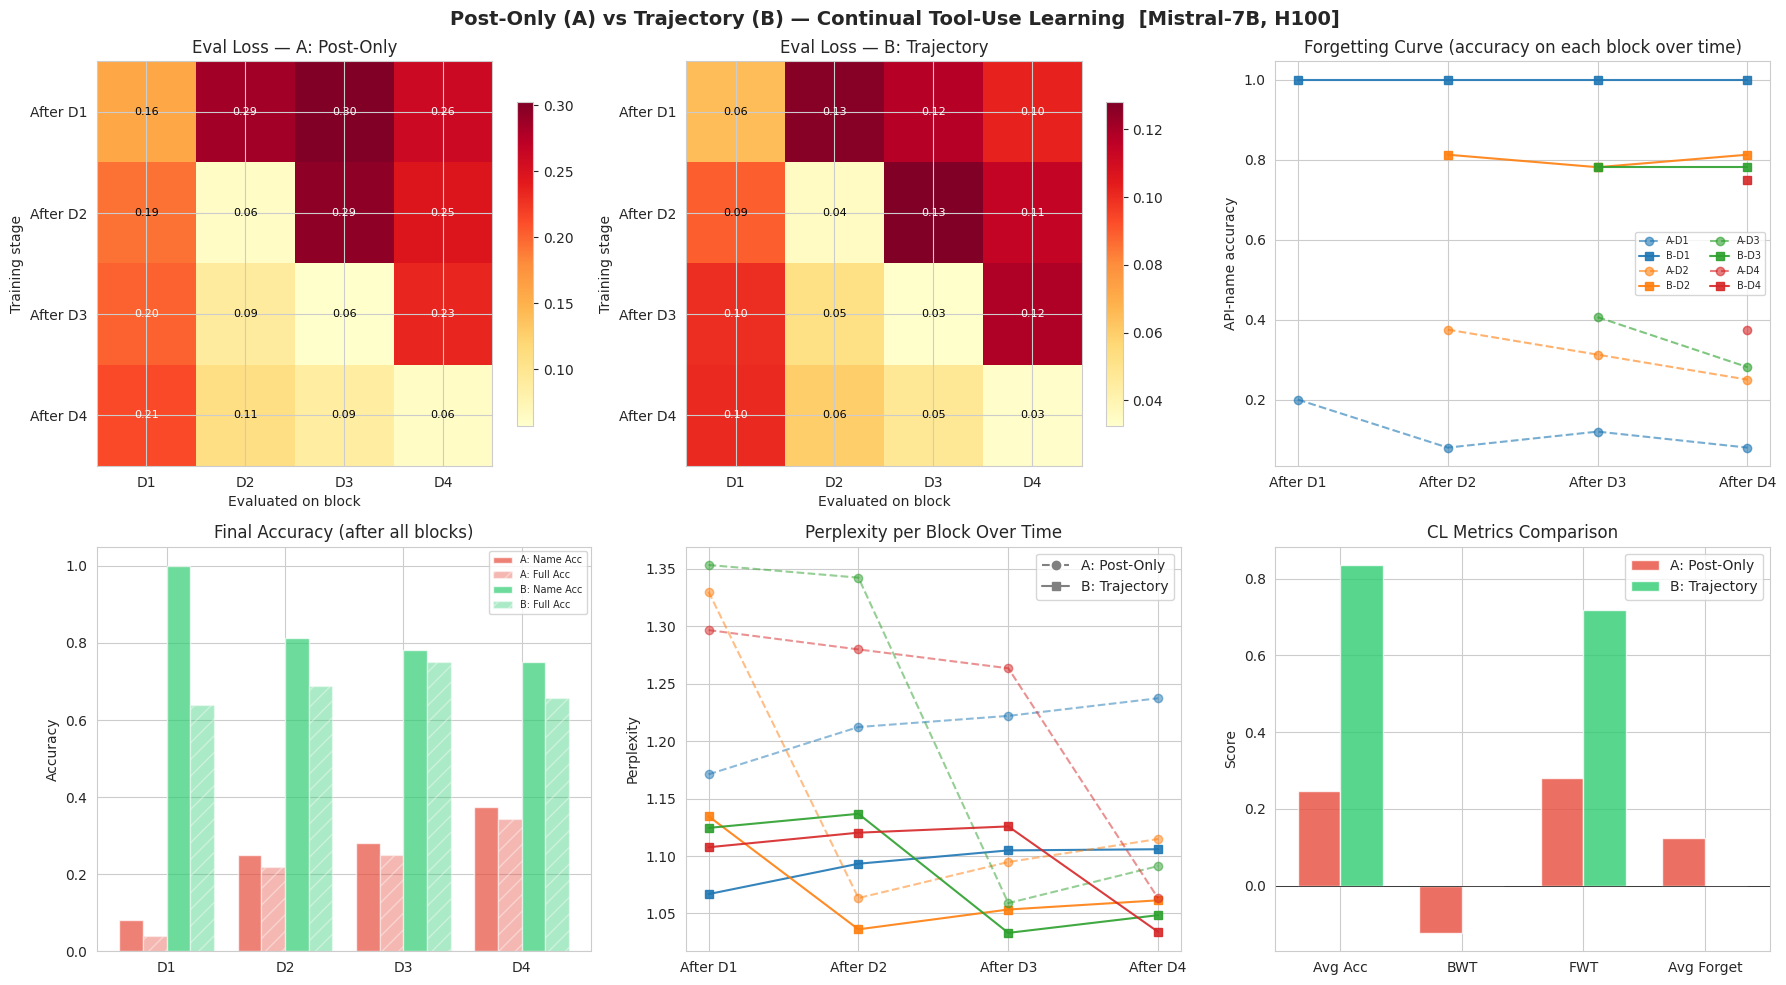


Figure saved to continual_learning_results.png


In [ ]:
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Post-Only (A) vs Trajectory (B) — Continual Tool-Use Learning  [Mistral-7B, H100]",
             fontsize=14, fontweight='bold')

num_blocks = len(domain_blocks)
block_labels = [f"D{i+1}" for i in range(num_blocks)]

# ---------- Plot 1: Eval loss heatmaps ----------
for idx, (results, title) in enumerate([(results_a, 'A: Post-Only'), (results_b, 'B: Trajectory')]):
    ax = axes[0, idx]
    im = ax.imshow(results['eval_loss'], cmap='YlOrRd', aspect='auto')
    ax.set_xticks(range(num_blocks))
    ax.set_yticks(range(num_blocks))
    ax.set_xticklabels(block_labels)
    ax.set_yticklabels([f"After {l}" for l in block_labels])
    ax.set_xlabel("Evaluated on block")
    ax.set_ylabel("Training stage")
    ax.set_title(f"Eval Loss — {title}")
    for i in range(num_blocks):
        for j in range(num_blocks):
            ax.text(j, i, f"{results['eval_loss'][i,j]:.2f}",
                    ha='center', va='center', fontsize=8,
                    color='white' if results['eval_loss'][i,j] > np.median(results['eval_loss']) else 'black')
    plt.colorbar(im, ax=ax, shrink=0.8)

# ---------- Plot 2: Forgetting curve (name accuracy over time) ----------
ax = axes[0, 2]
for j in range(num_blocks):
    stages = list(range(j, num_blocks))
    acc_a = [results_a['eval_acc'][i, j] for i in stages]
    acc_b = [results_b['eval_acc'][i, j] for i in stages]
    ax.plot(stages, acc_a, 'o--', color=f'C{j}', alpha=0.6, label=f'A-{block_labels[j]}')
    ax.plot(stages, acc_b, 's-', color=f'C{j}', alpha=0.9, label=f'B-{block_labels[j]}')
ax.set_xticks(range(num_blocks))
ax.set_xticklabels([f"After {l}" for l in block_labels])
ax.set_ylabel("API-name accuracy")
ax.set_title("Forgetting Curve (accuracy on each block over time)")
ax.legend(fontsize=7, ncol=2)

# ---------- Plot 3: Final accuracy per block (name + full) ----------
ax = axes[1, 0]
x = np.arange(num_blocks)
width = 0.2
ax.bar(x - 1.5*width, results_a['eval_acc'][-1], width, label='A: Name Acc', color='#e74c3c', alpha=0.7)
ax.bar(x - 0.5*width, results_a['eval_full_acc'][-1], width, label='A: Full Acc', color='#e74c3c', alpha=0.4, hatch='//')
ax.bar(x + 0.5*width, results_b['eval_acc'][-1], width, label='B: Name Acc', color='#2ecc71', alpha=0.7)
ax.bar(x + 1.5*width, results_b['eval_full_acc'][-1], width, label='B: Full Acc', color='#2ecc71', alpha=0.4, hatch='//')
ax.set_xticks(x)
ax.set_xticklabels(block_labels)
ax.set_ylabel("Accuracy")
ax.set_title("Final Accuracy (after all blocks)")
ax.legend(fontsize=7)

# ---------- Plot 4: Perplexity trajectory ----------
ax = axes[1, 1]
for j in range(num_blocks):
    stages = list(range(num_blocks))
    ppl_a = [results_a['eval_ppl'][i, j] for i in stages]
    ppl_b = [results_b['eval_ppl'][i, j] for i in stages]
    ax.plot(stages, ppl_a, 'o--', color=f'C{j}', alpha=0.5)
    ax.plot(stages, ppl_b, 's-', color=f'C{j}', alpha=0.9)
ax.set_xticks(range(num_blocks))
ax.set_xticklabels([f"After {l}" for l in block_labels])
ax.set_ylabel("Perplexity")
ax.set_title("Perplexity per Block Over Time")
from matplotlib.lines import Line2D
custom_lines = [Line2D([0], [0], linestyle='--', marker='o', color='gray'),
                Line2D([0], [0], linestyle='-', marker='s', color='gray')]
ax.legend(custom_lines, ['A: Post-Only', 'B: Trajectory'])

# ---------- Plot 5: Summary CL metrics ----------
ax = axes[1, 2]
metric_names = ['Average Accuracy (AA)', 'Backward Transfer (BWT)',
                'Forward Transfer (FWT)', 'Average Forgetting']
short_names = ['Avg Acc', 'BWT', 'FWT', 'Avg Forget']
vals_a = [metrics_a[m] for m in metric_names]
vals_b = [metrics_b[m] for m in metric_names]
x = np.arange(len(metric_names))
width = 0.35
ax.bar(x - width/2, vals_a, width, label='A: Post-Only', color='#e74c3c', alpha=0.8)
ax.bar(x + width/2, vals_b, width, label='B: Trajectory', color='#2ecc71', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(short_names)
ax.set_ylabel("Score")
ax.set_title("CL Metrics Comparison")
ax.legend()
ax.axhline(y=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig("continual_learning_results.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nFigure saved to continual_learning_results.png")

## 10. Detailed Results Table

In [ ]:
print("\n" + "=" * 80)
print("FULL EVALUATION MATRIX — CONDITION A (Post-Only)")
print("=" * 80)
print(f"{'':>15}", end="")
for j in range(num_blocks):
    print(f"{'Blk '+str(j+1)+' name':>12}{'Blk '+str(j+1)+' full':>12}", end="")
print()
for i in range(num_blocks):
    print(f"After Block {i+1:>2}: ", end="")
    for j in range(num_blocks):
        print(f"{results_a['eval_acc'][i,j]:>12.2%}{results_a['eval_full_acc'][i,j]:>12.2%}", end="")
    print()

print("\n" + "=" * 80)
print("FULL EVALUATION MATRIX — CONDITION B (Trajectory)")
print("=" * 80)
print(f"{'':>15}", end="")
for j in range(num_blocks):
    print(f"{'Blk '+str(j+1)+' name':>12}{'Blk '+str(j+1)+' full':>12}", end="")
print()
for i in range(num_blocks):
    print(f"After Block {i+1:>2}: ", end="")
    for j in range(num_blocks):
        print(f"{results_b['eval_acc'][i,j]:>12.2%}{results_b['eval_full_acc'][i,j]:>12.2%}", end="")
    print()

print("\n" + "=" * 80)
print("INTERPRETATION")
print("=" * 80)
bwt_diff = metrics_b['Backward Transfer (BWT)'] - metrics_a['Backward Transfer (BWT)']
aa_diff = metrics_b['Average Accuracy (AA)'] - metrics_a['Average Accuracy (AA)']
forget_diff = metrics_a['Average Forgetting'] - metrics_b['Average Forgetting']

print(f"Trajectory (B) vs Post-Only (A):")
print(f"  Average Accuracy difference:  {aa_diff:+.4f} ({'B better' if aa_diff > 0 else 'A better'})")
print(f"  BWT difference:               {bwt_diff:+.4f} ({'B forgets less' if bwt_diff > 0 else 'A forgets less'})")
print(f"  Forgetting reduction:         {forget_diff:+.4f} ({'B forgets less' if forget_diff > 0 else 'A forgets less'})")
print(f"\nModel: {MODEL_NAME}")
print(f"GPU: H100 80GB, bf16 + {ATTN_IMPLEMENTATION}")
print(f"LoRA: r=32, alpha=64, targets=q/k/v/o/gate/up/down")
print(f"Seq len: {MAX_SEQ_LEN}, Batch: {BATCH_SIZE}, Epochs/block: {NUM_EPOCHS_PER_BLOCK}")


FULL EVALUATION MATRIX — CONDITION A (Post-Only)
                 Blk 1 name  Blk 1 full  Blk 2 name  Blk 2 full  Blk 3 name  Blk 3 full  Blk 4 name  Blk 4 full
After Block  1:       20.00%       4.00%       9.38%       0.00%       6.25%       0.00%      12.50%       3.12%
After Block  2:        8.00%       4.00%      37.50%      31.25%      37.50%      37.50%      43.75%      40.62%
After Block  3:       12.00%       4.00%      31.25%      21.88%      40.62%      40.62%      37.50%      31.25%
After Block  4:        8.00%       4.00%      25.00%      21.88%      28.12%      25.00%      37.50%      34.38%

FULL EVALUATION MATRIX — CONDITION B (Trajectory)
                 Blk 1 name  Blk 1 full  Blk 2 name  Blk 2 full  Blk 3 name  Blk 3 full  Blk 4 name  Blk 4 full
After Block  1:      100.00%     100.00%      75.00%      68.75%      75.00%      75.00%      75.00%      62.50%
After Block  2:      100.00%      96.00%      81.25%      81.25%      75.00%      71.88%      68.75%      62.5

## 11. Save Results for Later Use

In [ ]:
results_all = {
    'results_a': {
        'condition': results_a['condition'],
        'eval_loss': results_a['eval_loss'].tolist(),
        'eval_ppl': results_a['eval_ppl'].tolist(),
        'eval_acc': results_a['eval_acc'].tolist(),
        'eval_full_acc': results_a['eval_full_acc'].tolist(),
        'train_losses': results_a['train_losses'],
    },
    'results_b': {
        'condition': results_b['condition'],
        'eval_loss': results_b['eval_loss'].tolist(),
        'eval_ppl': results_b['eval_ppl'].tolist(),
        'eval_acc': results_b['eval_acc'].tolist(),
        'eval_full_acc': results_b['eval_full_acc'].tolist(),
        'train_losses': results_b['train_losses'],
    },
    'metrics_a': metrics_a,
    'metrics_b': metrics_b,
    'config': {
        'model': MODEL_NAME,
        'num_blocks': NUM_BLOCKS,
        'epochs_per_block': NUM_EPOCHS_PER_BLOCK,
        'batch_size': BATCH_SIZE,
        'lr': LR,
        'max_seq_len': MAX_SEQ_LEN,
        'lora_r': 32,
        'lora_alpha': 64,
        'precision': 'bf16',
        'attn_implementation': ATTN_IMPLEMENTATION,
        'gpu': 'H100 80GB',
        'seed': SEED,
    },
}

with open('experiment_results.json', 'w') as f:
    json.dump(results_all, f, indent=2)

print("Results saved to experiment_results.json")
print("Figure saved to continual_learning_results.png")
print("\nDownload both files from Colab file browser (left sidebar).")

Results saved to experiment_results.json
Figure saved to continual_learning_results.png

Download both files from Colab file browser (left sidebar).


## 12. Next Steps

This H100 experiment gives publishable-quality A vs B results. For the full project:

1. **Condition C**: Add replay buffer + retrieval memory + confidence gating
2. **Multiple seeds**: Run 3 seeds per condition for confidence intervals / bootstrap CIs
3. **Token budget control**: Report performance as f(training tokens consumed) for fair comparison
4. **ECE & Brier score**: Add calibration metrics (sample multiple generations, measure confidence)
5. **ToolBench subset**: Replicate on a larger dataset for generalizability
6. **Exact-match eval**: Stricter API call matching (name + all parameters exact match)